<a href="https://colab.research.google.com/github/syedmahmoodiagents/Reinforce/blob/main/QLearning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import gym
import matplotlib.pyplot as plt

In [ ]:
# Initialize environment
env = gym.make("FrozenLake-v1", is_slippery=False)
Q = np.zeros((env.observation_space.n, env.action_space.n))  # Q-table

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.99  # Discount factor
epsilon = 1
epsilon_max = 1.0  # Initial exploration rate
epsilon_min = 0.01  # Final exploration rate
decay_rate = 0.001  # Decay rate for epsilon
num_episodes = 100
threshold = 1e-3  # Convergence threshold

In [ ]:
env.reset()

0

In [ ]:
for episode in range(num_episodes):
    state = env.reset()
    max_delta = 0  # Track max change in Q-values

    while True:
        # Select action using epsilon-greedy policy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(Q[state])  # Exploit

        next_state, reward, done, _= env.step(action)

        # Q-learning update
        old_value = Q[state, action]
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        # Track max change in Q-values
        max_delta = max(max_delta, abs(Q[state, action] - old_value))
        # print(max_delta)
        state = next_state
        if done:
            break

    # Decay epsilon to reduce exploration over time
    epsilon = max(epsilon_min, epsilon * 0.9)

    # Check for convergence
    if max_delta < threshold and epsilon < 0.05:  # Ensure epsilon is low
        print(f"Converged at episode {episode} with ε={epsilon:.4f}")
        break


Converged at episode 28 with ε=0.0471


In [ ]:
max_delta

0

In [ ]:
# !pip install --upgrade gym

In [ ]:
env.reset()

(0, {'prob': 1})

# with Graph

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
alpha = 0.1       # learning rate
gamma = 0.99      # discount factor
epsilon = 1.0     # initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995
num_episodes = 5000

In [ ]:
Q = np.zeros((n_states, n_actions))
episode_rewards = np.zeros(num_episodes)
max_delta_history = np.zeros(num_episodes)

In [ ]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q[state])

In [ ]:
# Training loop
for ep in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0.0
    max_delta = 0.0

    while not done:
        action = epsilon_greedy(Q, state, epsilon)
        next_state, reward, done, info = env.step(action)

        old = Q[state, action]
        target = reward + (0 if done else gamma * np.max(Q[next_state]))
        Q[state, action] = old + alpha * (target - old)

        delta = abs(Q[state, action] - old)
        max_delta = max(max_delta, delta)

        total_reward += reward
        state = next_state

    episode_rewards[ep] = total_reward
    max_delta_history[ep] = max_delta
    epsilon = max(epsilon_min, epsilon * epsilon_decay)


In [ ]:
# Convergence check
threshold = 1e-3
stable_window = 100
converged_at = None
for i in range(len(max_delta_history) - stable_window):
    if np.all(max_delta_history[i:i+stable_window] < threshold):
        converged_at = i
        break


In [ ]:
print("\nFinal Q-table (rounded):")
print(np.round(Q, 3))


Final Q-table (rounded):
[[0.941 0.951 0.951 0.941]
 [0.941 0.    0.961 0.951]
 [0.951 0.97  0.951 0.961]
 [0.961 0.    0.942 0.947]
 [0.94  0.961 0.    0.941]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.961]
 [0.    0.    0.    0.   ]
 [0.861 0.    0.97  0.91 ]
 [0.95  0.942 0.98  0.   ]
 [0.97  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.836 0.99  0.918]
 [0.98  0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]


In [ ]:
if converged_at:
    print(f"\nQ-values converged (delta < {threshold}) for {stable_window} episodes starting at {converged_at}")
else:
    print("\nQ-values did not fully stabilize within training window.")



Q-values did not fully stabilize within training window.


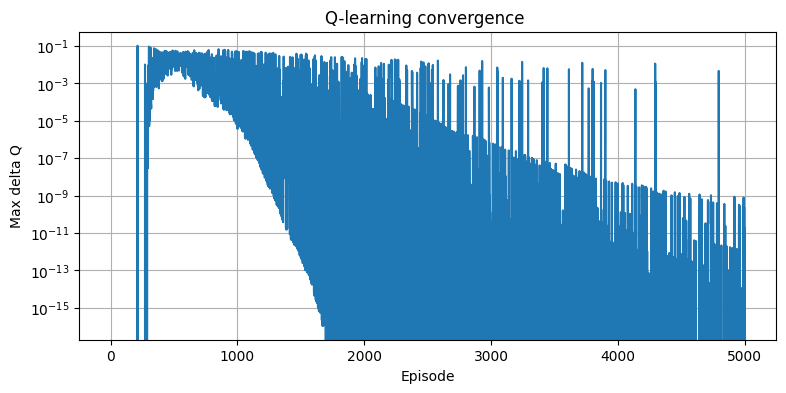

In [ ]:

# Plot convergence signals
plt.figure(figsize=(9,4))
plt.plot(max_delta_history)
plt.yscale('log')
plt.xlabel("Episode")
plt.ylabel("Max delta Q")
plt.title("Q-learning convergence ")
plt.grid(True)
plt.show()

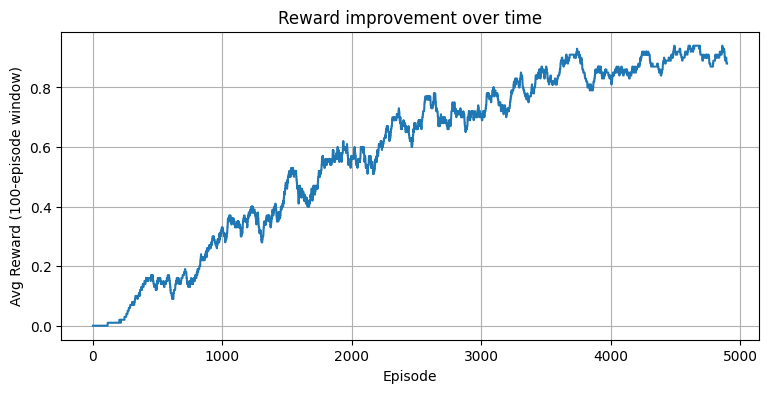

In [ ]:
# Reward curve
window = 100
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.figure(figsize=(9,4))
plt.plot(moving_avg)
plt.xlabel("Episode")
plt.ylabel("Avg Reward (100-episode window)")
plt.title("Reward improvement over time")
plt.grid(True)
plt.show()